## Importing Libraries

The following Python libraries are imported for data analysis and visualization:

- **Pandas (`pd`)** – Used for loading, cleaning, manipulating, and analyzing tabular data.
- **NumPy (`np`)** – Used for numerical operations and working with arrays.
- **Matplotlib (`plt`)** – Used for creating plots and visualizations.
- **Seaborn (`sns`)** – Used for creating statistical and visually appealing plots.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## Loading the Dataset

The Titanic dataset is loaded using Pandas' `read_csv()` function. The dataset is stored in a DataFrame named `df`.

To get a quick overview of the dataset, the `head()` function is used. It displays the first five rows of the DataFrame.

This helps us understand the dataset's structure, column names, and the type of values present before performing further analysis.


In [3]:
df = pd.read_csv("data/titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Shape

The `shape` attribute is used to determine the number of **rows and columns** in the Titanic dataset.


In [4]:
print("Shape:", df.shape)

Shape: (891, 12)


## Dataset Information

The `info()` function provides a summary of the Titanic dataset, including the number of entries, column names, data types, and non-null values.
    
This helps identify the **data types of each column** and detect **missing values**, which is useful for the data cleaning and preprocessing stage.


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## Missing Values

The `isnull().sum()` function is used to count the number of missing values in each column of the Titanic dataset.


This helps identify which columns contain missing data and determines where **data cleaning or missing-value treatment** may be required.


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Descriptive Statistics

The `describe()` function provides a statistical summary of the numerical columns in the Titanic dataset.

It includes measures such as **count, mean, standard deviation, minimum, maximum, and quartile values**. This helps understand the distribution and basic statistics of the numerical features.


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Column Data Types

The `dtypes` attribute is used to identify the data type of each column in the Titanic dataset.

This helps determine whether each feature is **numerical, categorical, or text-based**, which is important for selecting appropriate data cleaning and analysis techniques.


In [8]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

## Duplicate Rows

The `duplicated().sum()` function is used to count the number of duplicate rows in the Titanic dataset.

This helps identify whether the dataset contains **repeated records** that may need to be removed during the data cleaning process.


In [9]:
df.duplicated().sum()

np.int64(0)

## Viewing Duplicate Rows

The following code is used to display all the duplicate rows present in the Titanic dataset.


This helps us **inspect the duplicate records** and determine whether they are genuine duplicates or valid repeated entries before deciding how to handle them.


In [10]:
df[df.duplicated()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


## Missing Values in Age

The following code checks the number of missing values specifically in the `Age` column.


This helps identify how many passengers have **missing age information**, which is important because `Age` is a numerical feature that may require missing-value treatment during data cleaning.


In [11]:
df["Age"].isnull().sum()

np.int64(177)

## Handling Missing Age Values

Missing values in the `Age` column are replaced with the **median age**.


**Rationale:** Since `Age` is a numerical variable, the median is used to fill missing values. The median is less affected by **outliers and extreme values** than the mean, making it a more robust choice for this dataset.


In [12]:
df["Age"] = df["Age"].fillna(df["Age"].median())

## Missing Values in Embarked

The following code checks the number of missing values in the `Embarked` column.

This helps determine whether the `Embarked` column contains missing values that need to be handled during the data cleaning process.


In [13]:
df["Embarked"].isnull().sum()

np.int64(2)

## Handling Missing Embarked Values

Missing values in the `Embarked` column are replaced with the **mode**, which is the most frequently occurring value.

**Rationale:** `Embarked` is a **categorical variable**, so the mode is appropriate for filling missing values. Since only a small number of values are missing, replacing them with the most common category minimizes the impact on the dataset.


In [14]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

## Missing Values in Cabin

The `Cabin` column contains a high percentage of missing values. The following code calculates the percentage of missing values in this column.


In [15]:
df["Cabin"].isnull().mean() * 100

np.float64(77.10437710437711)


### Create `CabinKnown` feature

```markdown
## Creating CabinKnown Feature

A new binary feature, `CabinKnown`, is created to indicate whether cabin information is available for each passenger.


In [16]:
df["CabinKnown"] = df["Cabin"].notna().astype(int)


### Remove the original `Cabin` column

Since the `Cabin` column contains a large proportion of missing values, the original column is removed from the dataset.
**Rationale:** The `Cabin` column was mostly missing, so the original column was removed instead of filling the missing values with potentially misleading information. The `CabinKnown` feature was retained to preserve whether cabin information was available.

In [17]:
df = df.drop(columns=["Cabin"])

## Checking for Duplicate Rows

The `duplicated().sum()` function is used to count the number of duplicate rows in the dataset.


In [18]:
df.duplicated().sum()

np.int64(0)

## Checking Data Types

The `dtypes` attribute is used to display the data type of each column in the dataset.


In [19]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Embarked           str
CabinKnown       int64
dtype: object

## Converting Columns to Categorical Type

The `Sex`, `Embarked`, and `Pclass` columns are converted to the **categorical data type**.
**Rationale:** `Sex`, `Embarked`, and `Pclass` represent categorical groups rather than continuous numerical measurements, so they were converted to categorical types.

In [20]:
df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")
df["Pclass"] = df["Pclass"].astype("category")

## Descriptive Statistics for Age and Fare

The following code generates descriptive statistics for the `Age` and `Fare` columns.


In [21]:
df[["Age", "Fare"]].describe()

,Age,Fare
count,891.000000,891.000000
mean,29.361582,32.204208
std,13.019697,49.693429
min,0.420000,0.000000
25%,22.000000,7.910400
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


## Boxplot of Age and Fare

A boxplot is created to visualize the distribution of the `Age` and `Fare` columns and identify potential outliers.

**Rationale:** Extreme `Fare` values were retained because they may represent genuine high-paying passengers rather than data-entry errors. Removing them could result in the loss of meaningful information from the dataset.


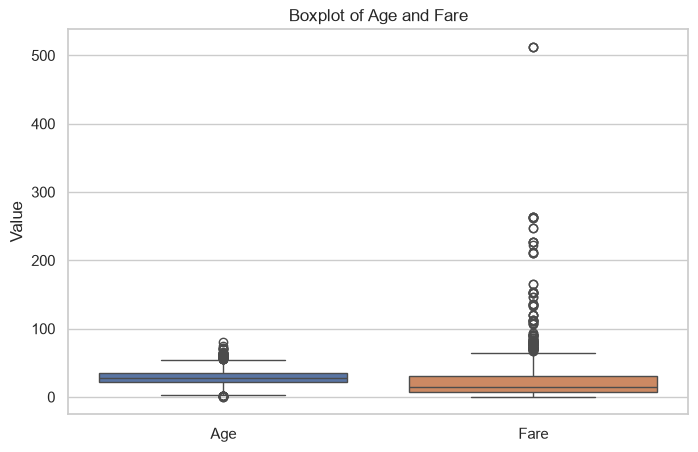

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df[["Age", "Fare"]])

plt.title("Boxplot of Age and Fare")
plt.ylabel("Value")

plt.show()

## Creating FamilySize Feature

A new feature called `FamilySize` is created by combining the `SibSp` (siblings/spouses) and `Parch` (parents/children) columns.

Rationale: FamilySize was derived from SibSp and Parch to represent the total number of people in the passenger's family group.

In [23]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

## Checking Dataset Information

The `info()` function is used again to verify the current structure of the dataset after data cleaning and feature engineering.


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    category
 3   Name         891 non-null    str     
 4   Sex          891 non-null    category
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
 11  CabinKnown   891 non-null    int64   
 12  FamilySize   891 non-null    int64   
dtypes: category(3), float64(2), int64(6), str(2)
memory usage: 72.4 KB


## Checking Remaining Missing Values

The `isnull().sum()` function is used to check the number of missing values remaining in each column after data cleaning.


In [25]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
CabinKnown     0
FamilySize     0
dtype: int64

## Previewing the Cleaned Dataset

The `head()` function is used to display the first five rows of the dataset after the data cleaning and feature engineering steps.


In [26]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,CabinKnown,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,1


## Visualization 1 — Gender and Survival

### Question

**Did survival differ between male and female passengers?**


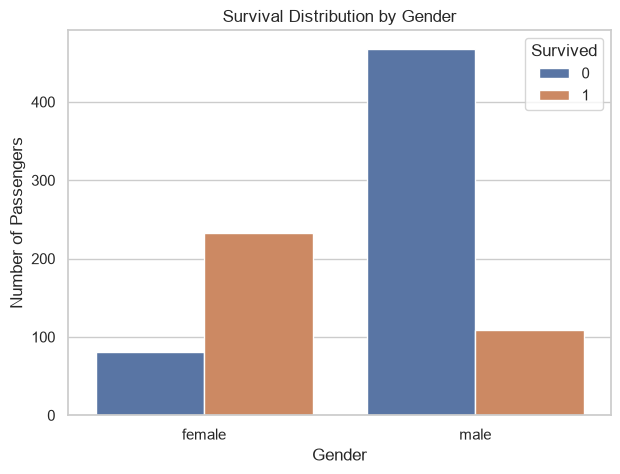

In [27]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Sex",
    hue="Survived"
)

plt.title("Survival Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

### Survival Rate Calculation

The actual survival rate for each gender is calculated using:

In [28]:
df.groupby("Sex", observed=True)["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

## Insights from Visualization 1 — Gender and Survival

- Female passengers had a **much higher survival rate (74.20%)** compared with male passengers (**18.89%**).
- The visualization shows a **strong association between gender and survival**.
- Although there were more male passengers, a much larger proportion of female passengers survived.
- This suggests that **gender was an important factor associated with survival outcomes** on the Titanic.

## Visualization 2 — Passenger Class

### Question

**Was passenger class associated with survival?**

### Visualization


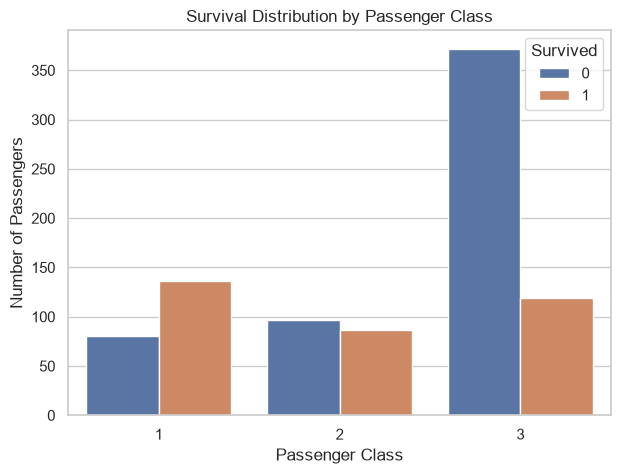

In [29]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

### Survival Rate Calculation

The actual survival rate for each gender is calculated using:

In [30]:
df.groupby("Pclass", observed=True)["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

## Insights from Visualization 2 — Passenger Class

- **1st-class passengers had the highest survival rate at 62.96%.**
- **2nd-class passengers had a survival rate of 47.28%.**
- **3rd-class passengers had the lowest survival rate at 24.24%.**
- Survival decreased consistently as passenger class increased from **1st to 3rd class**.
- This indicates that **passenger class was strongly associated with survival outcomes**, with higher-class passengers having a greater likelihood of survival.

## Visualization 3 — Age

### Question

**How does the age distribution differ between survivors and non-survivors?**


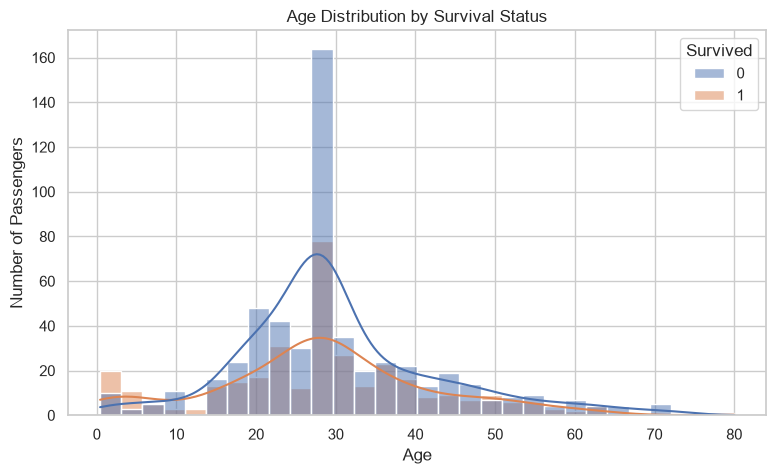

In [31]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

## Insights from Visualization 3 — Age

- The majority of passengers were **young to middle-aged adults**, with the highest concentration around the **20–35 age range**.
- The survivor distribution shows a relatively noticeable concentration among **younger passengers and children**.
- Non-survivors were more heavily concentrated around the **20–40 age range**.
- Among older passengers, the number of survivors generally decreased as age increased.
- Overall, **age appears to have some association with survival**, but the distributions overlap considerably, indicating that age alone was not the primary determinant of survival.

## Visualization 4 — Fare

### Question

**Was passenger fare associated with survival?**

### Visualization

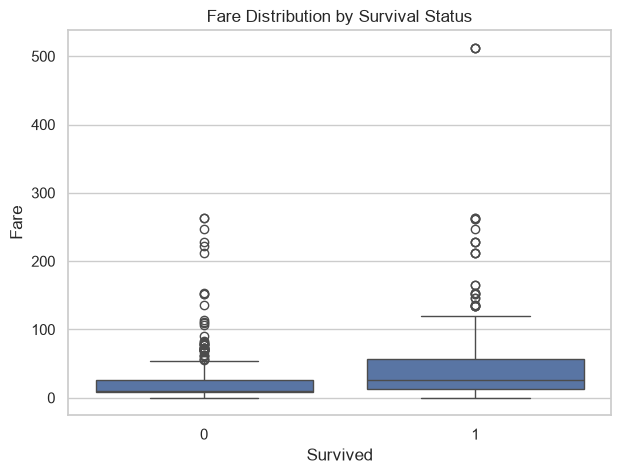

In [32]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Survived",
    y="Fare"
)

plt.title("Fare Distribution by Survival Status")
plt.xlabel("Survived")
plt.ylabel("Fare")

plt.show()

### Median Fare Comparison

The median fare for survivors and non-survivors is calculated using:

In [33]:
df.groupby("Survived")["Fare"].median()

Survived
0    10.5
1    26.0
Name: Fare, dtype: float64

## Insights from Visualization 4 — Fare

- Passengers who survived generally had a **higher median fare** than those who did not survive.
- The fare distribution for survivors is more spread out, with several **high-fare outliers**.
- Non-survivors generally paid lower fares, although there is considerable overlap between the two groups.
- This suggests that **higher fare was associated with a greater likelihood of survival**.
- Since fare is related to passenger class, this finding is consistent with the earlier observation that **higher-class passengers had better survival rates**.

## Visualization 5 — Family Size

### Question

**Did family size influence survival?**

### Survival Rate Calculation

In [34]:
survival_by_family = df.groupby("FamilySize")["Survived"].mean()
survival_by_family

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

## Visualization — Survival Rate by Family Size

The bar plot visualizes the survival rate for each family size. This makes it easier to compare how survival varied among passengers traveling alone, with small families, and with larger family groups.


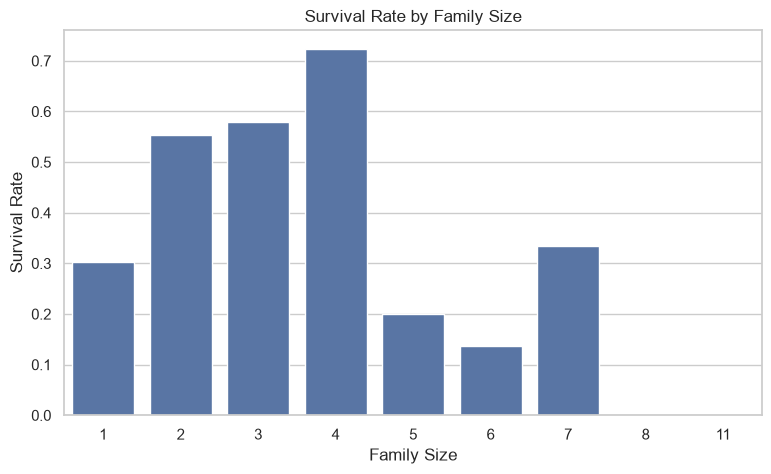

In [35]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=survival_by_family.index,
    y=survival_by_family.values
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")

plt.show()

## Insights from Visualization 5 — Family Size

- Passengers traveling alone (**FamilySize = 1**) had a survival rate of approximately **30.3%**.
- Passengers in small family groups had higher survival rates, with **FamilySize = 4** having the highest rate at approximately **72.4%**.
- Survival decreased sharply for larger families, with **FamilySize = 5** at **20.0%** and **FamilySize = 6** at **13.6%**.
- Family sizes **8 and 11** had a survival rate of **0%** in this dataset.
- Overall, the relationship between family size and survival was **non-linear**: small family groups generally had better survival outcomes, while very large families had lower survival rates.

## Deeper Analysis 1 — Gender and Passenger Class

### Question

Does the relationship between gender and survival change across passenger classes?

In [36]:
gender_class = df.groupby(
    ["Pclass", "Sex"],
    observed=True
)["Survived"].agg(
    ["count", "mean"]
).round(3)

gender_class

count   mean
Pclass Sex                 
1      female     94  0.968
       male      122  0.369
2      female     76  0.921
       male      108  0.157
3      female    144  0.500
       male      347  0.135

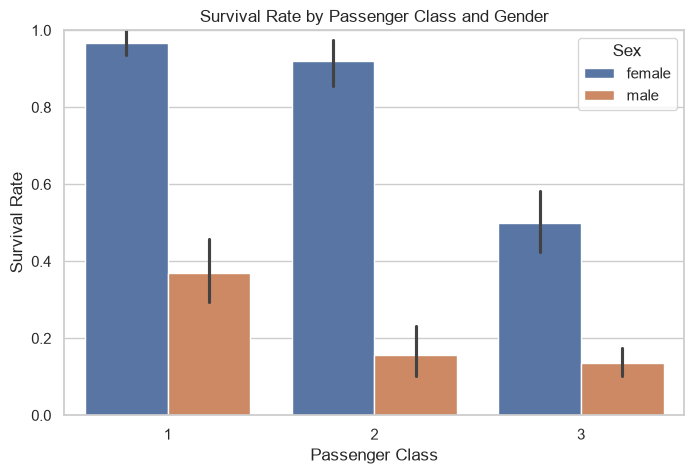

In [37]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Sex"
)

plt.title("Survival Rate by Passenger Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.show()

### Insight

Survival differed substantially across combinations of gender and passenger class. Female passengers had higher survival rates than males in every class, but passenger class also had a strong effect within each gender. Female survival decreased from 96.8% in first class to 50.0% in third class, while male survival decreased from 36.9% to 13.5%. The highest survival was among first-class females, while third-class males had the lowest survival rate.

## Deeper Analysis 2 — Family Group

### Question

Does survival differ between passengers traveling alone, in small families, and in large families?

In [38]:
def family_group(size):
    if size == 1:
        return "Alone"
    elif size <= 4:
        return "Small"
    else:
        return "Large"

df["FamilyGroup"] = df["FamilySize"].apply(family_group)

## Family Group Summary

The following code summarizes the number of passengers and the average survival rate for each `FamilyGroup`.


In [39]:
family_summary = df.groupby("FamilyGroup")["Survived"].agg(
    ["count", "mean"]
).round(3)

family_summary

,count,mean
FamilyGroup,,
Alone,537,0.304
Large,62,0.161
Small,292,0.579


## Visualization — Survival Rate by Family Group

The bar plot compares the **survival rate across different family groups**.

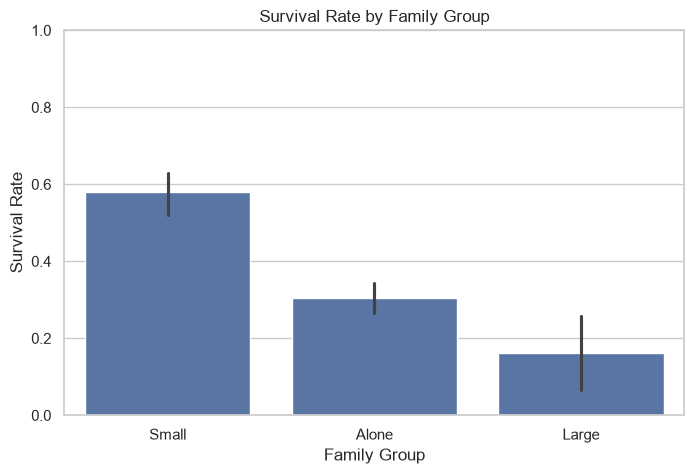

In [40]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="FamilyGroup",
    y="Survived"
)

plt.title("Survival Rate by Family Group")
plt.xlabel("Family Group")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.show()

## Insights from Family Group Visualization

- Passengers traveling **alone** had a lower survival rate compared with passengers traveling in **small family groups**.
- **Small families** generally had the highest survival rates, suggesting that traveling with a few family members may have provided a survival advantage.
- **Large families** had noticeably lower survival rates than small families.
- Grouping family sizes into `Alone`, `Small`, and `Large` reduces the influence of groups with very few observations, such as FamilySize 8 and 11.
- Overall, the results suggest a **non-linear relationship between family size and survival**, where small family groups had better outcomes than both solo passengers and large family groups.

## Deeper Analysis 3 — Age and Passenger Class

### Question

Did survival vary across age groups differently for passengers in different classes?

In [41]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 40, 60, 100],
    labels=["Child", "Teen", "Adult", "Middle-aged", "Senior"]
)

## Age Group and Passenger Class

The `age_class` table summarizes the **number of passengers (`count`)** and **average survival rate (`mean`)** for each combination of passenger class and age group.

- `count` shows how many passengers belong to each **Pclass–AgeGroup** combination.
- `mean` represents the **survival rate** for that group.
- Grouping by both `Pclass` and `AgeGroup` helps determine whether the relationship between **age and survival differs across passenger classes**.
- For example, in **1st class**, teenagers had a very high survival rate (`91.7%`), while adults had a lower survival rate (`66.9%`).
- This analysis allows us to identify whether **passenger class and age together influenced survival outcomes** more clearly than looking at either variable separately.

In [43]:
age_class = df.groupby(
    ["Pclass", "AgeGroup"],
    observed=True
)["Survived"].agg(
    ["count", "mean"]
).round(3)

age_class

count   mean
Pclass AgeGroup                 
1      Child            4  0.750
       Teen            12  0.917
       Adult          124  0.669
       Middle-aged     62  0.581
       Senior          14  0.214
2      Child           17  1.000
       Teen            12  0.500
       Adult          121  0.421
       Middle-aged     31  0.387
       Senior           3  0.333
3      Child           48  0.417
       Teen            46  0.283
       Adult          357  0.232
       Middle-aged     35  0.057
       Senior           5  0.200

## Visualization: Survival Rate by Age Group and Passenger Class

This bar plot compares the **survival rate across different age groups** for each **passenger class**.

- The x-axis represents the different `AgeGroup` categories.
- The y-axis represents the average `Survived` value, which corresponds to the **survival rate**.
- Different colors represent the three passenger classes (`Pclass`).
- This visualization helps identify whether **age affected survival differently across passenger classes**.
- Comparing the bars within each age group shows how **passenger class influenced survival among people of similar ages**.

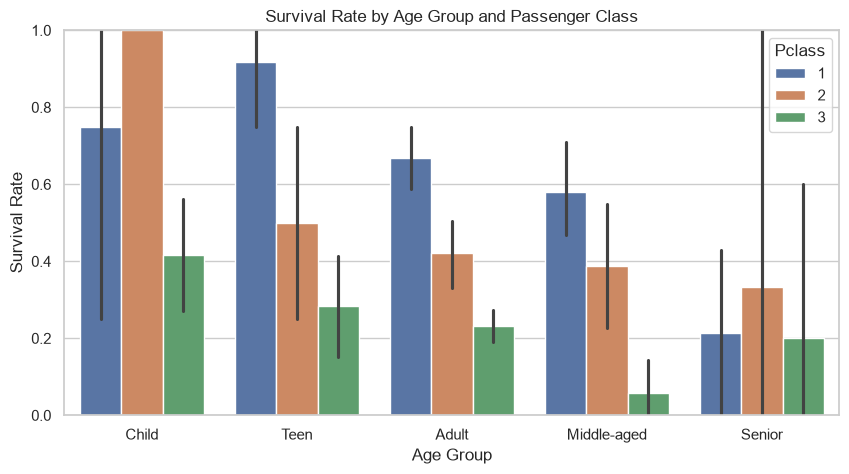

In [44]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="AgeGroup",
    y="Survived",
    hue="Pclass"
)

plt.title("Survival Rate by Age Group and Passenger Class")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.show()

In [45]:
age_class

count   mean
Pclass AgeGroup                 
1      Child            4  0.750
       Teen            12  0.917
       Adult          124  0.669
       Middle-aged     62  0.581
       Senior          14  0.214
2      Child           17  1.000
       Teen            12  0.500
       Adult          121  0.421
       Middle-aged     31  0.387
       Senior           3  0.333
3      Child           48  0.417
       Teen            46  0.283
       Adult          357  0.232
       Middle-aged     35  0.057
       Senior           5  0.200

## Insights: Age Group and Passenger Class

- **Passenger class had a strong effect on survival across most age groups.**
- **1st-class passengers generally had the highest survival rates**, especially among teenagers and adults.
- **3rd-class passengers had the lowest survival rates** across most age groups.
- **Children in 2nd class show a very high survival rate**, but this group has very few observations, so the result should be interpreted cautiously.
- Survival generally **decreased with age**, particularly for passengers in 3rd class.
- Among **middle-aged passengers**, the difference between classes is especially clear: 1st class had much higher survival than 3rd class.
- Overall, the visualization suggests that **age and passenger class jointly influenced survival**, with passenger class remaining an important factor even within similar age groups.

# Data Quality and Modeling Risks

## 1. Target Leakage

`Survived` is the target variable and must not be used as an input feature when training a predictive model. Including it as a feature would directly reveal the outcome to the model and cause target leakage.

## 2. Identifier Risk

`PassengerId` is an identifier rather than a meaningful passenger characteristic. It should generally be excluded from model features because its numeric value does not represent a meaningful passenger attribute.

## 3. High Cabin Missingness

Approximately 77% of the original `Cabin` values were missing. Instead of imputing cabin values, a `CabinKnown` indicator was created to preserve whether cabin information was available. The high missingness should be considered when interpreting this feature in a model.

## 4. Imputed Age

Missing `Age` values were replaced with the median. This avoids losing records but introduces identical imputed values for all missing observations and may affect downstream modeling.

# Conclusion

The Titanic dataset contains 891 passenger records with substantial missingness in `Cabin` and `Age` and a small number of missing `Embarked` values. After cleaning, missing values were handled, categorical types were corrected, duplicates were checked, and potential outliers were investigated without automatically removing valid extreme observations.

The analysis shows that survival was strongly associated with passenger class and gender, while family size showed a non-linear relationship with survival. Deeper analysis showed that passenger class remained important when examining survival across gender and age groups.

The analysis also identified important modeling risks, including target leakage from `Survived`, the identifier nature of `PassengerId`, substantial missingness in `Cabin`, and the effect of median imputation on `Age`.